In [1]:
import pandas as pd
import numpy as np

In [2]:
file = "data/train.csv"
df = pd.read_csv(file, header=0)
df.head()

,user,item,rating
0,1,25715,7.0
1,1,25716,10.0
2,5,25851,9.0
3,6,25923,5.0
4,7,25924,6.0


In [3]:
df["rating"].min()

np.float64(1.0)

In [4]:
df["user"].unique().shape[0]

73456

In [5]:
df.shape

(390351, 3)

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
y = df["rating"]
x = df.drop(columns="rating")

In [8]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.1, random_state=42, stratify=df.rating)

In [9]:
x_train.shape, x_val.shape

((351315, 2), (39036, 2))

In [10]:
from scipy.sparse import csr_matrix

# Map users and items to contiguous indices (0, 1, 2, ...)
# This is necessary since your IDs are not sequential
user_map = {u: i for i, u in enumerate(df['user'].unique())}
item_map = {it: i for i, it in enumerate(df['item'].unique())}

row = df['user'].map(user_map)
col = df['item'].map(item_map)
data = df['rating'].values

sparse_matrix = csr_matrix(
    (data, (row, col)),
    shape=(len(user_map), len(item_map))
)

print(sparse_matrix.shape)   # (n_users, n_items)
print(sparse_matrix)         # Shows non-zero entries

(73456, 171171)
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 390351 stored elements and shape (73456, 171171)>
  Coords	Values
  (0, 0)	7.0
  (0, 1)	10.0
  (1, 2)	9.0
  (2, 3)	5.0
  (3, 4)	6.0
  (3, 5)	7.0
  (3, 6)	7.0
  (3, 7)	9.0
  (3, 8)	7.0
  (3, 9)	9.0
  (4, 10)	10.0
  (4, 11)	10.0
  (4, 12)	7.0
  (4, 13)	8.0
  (5, 14)	9.0
  (5, 15)	9.0
  (5, 16)	10.0
  (5, 17)	9.0
  (5, 18)	9.0
  (5, 19)	9.0
  (5, 20)	9.0
  (5, 21)	10.0
  (5, 22)	9.0
  (5, 23)	9.0
  (6, 24)	8.0
  :	:
  (73451, 25685)	10.0
  (73451, 31261)	10.0
  (73451, 35965)	8.0
  (73451, 38130)	6.0
  (73451, 44349)	10.0
  (73451, 54135)	10.0
  (73451, 66553)	7.0
  (73451, 74424)	10.0
  (73451, 75782)	9.0
  (73451, 129549)	7.0
  (73451, 147312)	6.0
  (73451, 158853)	2.0
  (73451, 171163)	8.0
  (73451, 171164)	10.0
  (73451, 171165)	2.0
  (73451, 171166)	6.0
  (73451, 171167)	7.0
  (73452, 159)	6.0
  (73452, 412)	7.0
  (73452, 132068)	9.0
  (73452, 171168)	5.0
  (73452, 171169)	5.0
  (73453, 16561)	10.0
  (73454

In [11]:
def distance_between_users(sparse_matrix, user_a, user_b, metric='cosine'):
    """
    Calcula distancia entre dos usuarios solo sobre ítems que ambos han valorado.
    """
    # Obtener vectores de ratings de cada usuario
    vec_a = sparse_matrix[user_a].toarray().flatten()
    vec_b = sparse_matrix[user_b].toarray().flatten()

    # Máscara: ítems valorados por AMBOS (entrada != 0 en los dos)
    common_mask = (vec_a != 0) & (vec_b != 0)
    n_common = common_mask.sum()

    if n_common == 0:
        return np.inf  # Sin ítems en común, distancia indefinida

    a_common = vec_a[common_mask]
    b_common = vec_b[common_mask]

    if metric == 'cosine':
        dot = np.dot(a_common, b_common)
        norm = np.linalg.norm(a_common) * np.linalg.norm(b_common)
        return 1 - np.abs(dot / norm)  # 0 = idénticos, 1 = opuestos

    elif metric == 'euclidean':
        return np.sqrt(np.sum((a_common - b_common) ** 2))

    elif metric == 'pearson':
        correlation = np.corrcoef(a_common, b_common)[0, 1]
        return 1 - correlation  # convertimos similitud a distancia

In [12]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
from tqdm import tqdm

In [13]:
def get_user_distances_for_item(user_idx, item_idx, sparse_matrix, metric='cosine'):
    """
    Calcula la distancia de user_idx SOLO a los usuarios que han valorado item_idx.
    Devuelve (distances, ratings, candidate_indices).
    """
    vec_a = sparse_matrix[user_idx].toarray().flatten()
    nonzero_a = set(np.where(vec_a != 0)[0])

    # Filtro clave: solo usuarios que han valorado este item
    item_col = sparse_matrix[:, item_idx].toarray().flatten()
    candidate_indices = np.where((item_col != 0) & (np.arange(len(item_col)) != user_idx))[0]

    if len(candidate_indices) == 0:
        return np.array([]), np.array([]), np.array([])

    distances = []
    ratings   = []
    valid_idx = []

    for j in candidate_indices:
        vec_b = sparse_matrix[j].toarray().flatten()
        common = list(nonzero_a & set(np.where(vec_b != 0)[0]))

        if len(common) == 0:
            continue

        a, b = vec_a[common], vec_b[common]

        if metric == 'cosine':
            norm = np.linalg.norm(a) * np.linalg.norm(b)
            if norm == 0:
                continue
            dist = 1 - (np.dot(a, b) / norm)

        elif metric == 'euclidean':
            dist = np.sqrt(np.sum((a - b) ** 2))

        elif metric == 'pearson':
            if np.std(a) == 0 or np.std(b) == 0:
                continue
            dist = 1 - np.corrcoef(a, b)[0, 1]

        distances.append(dist)
        ratings.append(item_col[j])
        valid_idx.append(j)

    return np.array(distances), np.array(ratings), np.array(valid_idx)


def evaluate_knn(x_val, y_val, sparse_matrix, user_map, item_map,
                 k_max=20, metric='cosine', error_metric='rmse'):
    """
    Para cada entrada de validación:
      1. Filtra candidatos que han valorado ese item
      2. Calcula distancias solo a esos candidatos
      3. Evalúa para k=2..k_max reutilizando el mismo cómputo
    """
    k_values = list(range(2, k_max + 1))

    val_df = x_val.copy()
    val_df['y_true'] = y_val.values
    val_df.columns = ['user', 'item', 'y_true']

    all_errors = {k: [] for k in k_values}

    for _, row in tqdm(val_df.iterrows(), total=len(val_df), desc="Evaluating"):
        user_id, item_id, y_true = row['user'], row['item'], row['y_true']

        if user_id not in user_map or item_id not in item_map:
            continue

        user_idx = user_map[user_id]
        item_idx = item_map[item_id]

        # 1. Filtrar por usuarios que han valorado el item + calcular distancias
        distances, ratings, _ = get_user_distances_for_item(
            user_idx, item_idx, sparse_matrix, metric
        )

        if len(distances) == 0:
            continue

        sorted_idx = np.argsort(distances)

        # 2. Reutilizar para todos los k
        for k in k_values:
            k_actual = min(k, len(sorted_idx))
            top_idx  = sorted_idx[:k_actual]
            top_d    = distances[top_idx]
            top_r    = ratings[top_idx]
            weights  = 1 / (top_d + 1e-8)
            pred     = np.dot(weights, top_r) / weights.sum()

            error = (pred - y_true) ** 2 if error_metric == 'rmse' else abs(pred - y_true)
            all_errors[k].append(error)

    errors = []
    for k in k_values:
        vals = all_errors[k]
        err  = np.sqrt(np.mean(vals)) if error_metric == 'rmse' else np.mean(vals)
        errors.append(err)

    return k_values, errors


def plot_knn_error(k_values, errors, error_metric='rmse'):
    best_k = k_values[np.argmin(errors)]

    plt.figure(figsize=(10, 5))
    plt.plot(k_values, errors, marker='o', linewidth=2)
    plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
    plt.xlabel('k')
    plt.ylabel(error_metric.upper())
    plt.title(f'Validation error vs k  —  Best k={best_k} ({error_metric.upper()}={min(errors):.4f})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return best_k

In [14]:
k_values, k_errors = evaluate_knn(x_val, y_val, sparse_matrix, user_map, item_map,
                 k_max=5, metric='cosine', error_metric='rmse')

Evaluating: 100%|██████████| 39036/39036 [03:07<00:00, 208.59it/s]


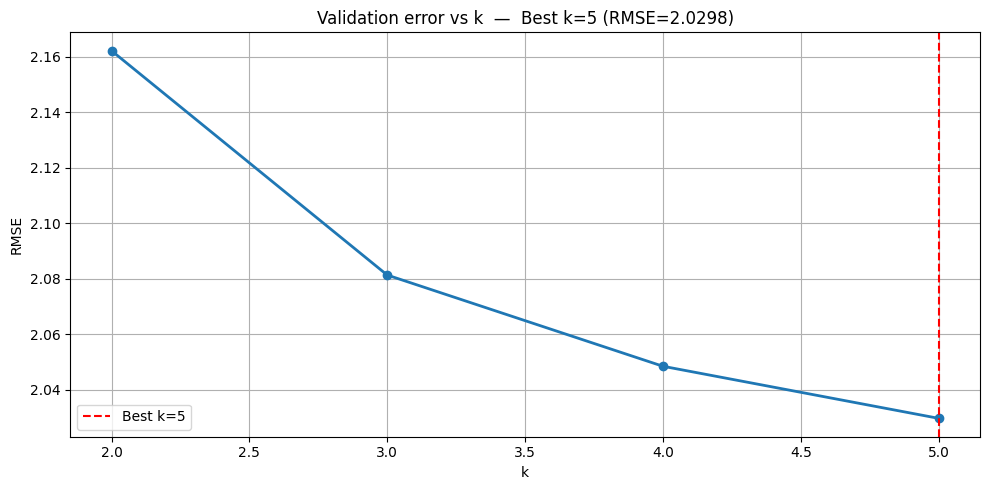

5

In [16]:
plot_knn_error(k_values, k_errors)

In [18]:
def get_user_distances_for_item(user_idx, item_idx, sparse_matrix, metrics):
    """
    Calcula distancias para TODAS las métricas a la vez en un solo paso.
    Devuelve dict {metric: distances}, más ratings y candidate_indices.
    """
    vec_a = sparse_matrix[user_idx].toarray().flatten()
    nonzero_a = set(np.where(vec_a != 0)[0])

    item_col = sparse_matrix[:, item_idx].toarray().flatten()
    candidate_indices = np.where((item_col != 0) & (np.arange(len(item_col)) != user_idx))[0]

    if len(candidate_indices) == 0:
        return {m: np.array([]) for m in metrics}, np.array([]), np.array([])

    distances = {m: [] for m in metrics}
    ratings   = []
    valid_idx = []

    for j in candidate_indices:
        vec_b = sparse_matrix[j].toarray().flatten()
        common = list(nonzero_a & set(np.where(vec_b != 0)[0]))

        if len(common) == 0:
            continue

        a, b = vec_a[common], vec_b[common]

        # Calcular todas las métricas para este par de una vez
        metric_results = {}

        if 'cosine' in metrics:
            norm = np.linalg.norm(a) * np.linalg.norm(b)
            metric_results['cosine'] = 1 - (np.dot(a, b) / norm) if norm > 0 else None

        if 'euclidean' in metrics:
            metric_results['euclidean'] = np.sqrt(np.sum((a - b) ** 2))

        if 'pearson' in metrics:
            if np.std(a) == 0 or np.std(b) == 0:
                metric_results['pearson'] = None
            else:
                metric_results['pearson'] = 1 - np.corrcoef(a, b)[0, 1]

        # Solo añadir si todas las métricas son válidas para este par
        if any(v is None for v in metric_results.values()):
            continue

        for m in metrics:
            distances[m].append(metric_results[m])
        ratings.append(item_col[j])
        valid_idx.append(j)

    return (
        {m: np.array(distances[m]) for m in metrics},
        np.array(ratings),
        np.array(valid_idx)
    )


def evaluate_knn(x_val, y_val, sparse_matrix, user_map, item_map,
                 k_max=20, metrics=('cosine',), error_metric='rmse'):
    """
    Evalúa k=2..k_max para cada métrica de distancia.
    Devuelve dict {metric: (k_values, errors)}.
    """
    metrics  = list(metrics)
    k_values = list(range(2, k_max + 1))

    val_df = x_val.copy()
    val_df['y_true'] = y_val.values
    val_df.columns   = ['user', 'item', 'y_true']

    # all_errors[metric][k] = lista de errores individuales
    all_errors = {m: {k: [] for k in k_values} for m in metrics}

    for _, row in tqdm(val_df.iterrows(), total=len(val_df), desc="Evaluating"):
        user_id, item_id, y_true = row['user'], row['item'], row['y_true']

        if user_id not in user_map or item_id not in item_map:
            continue

        user_idx = user_map[user_id]
        item_idx = item_map[item_id]

        # Calcular distancias para TODAS las métricas a la vez
        dist_by_metric, ratings, _ = get_user_distances_for_item(
            user_idx, item_idx, sparse_matrix, metrics
        )

        if len(ratings) == 0:
            continue

        for m in metrics:
            distances  = dist_by_metric[m]
            if len(distances) == 0:
                continue

            sorted_idx = np.argsort(distances)

            for k in k_values:
                k_actual = min(k, len(sorted_idx))
                top_idx  = sorted_idx[:k_actual]
                top_d    = distances[top_idx]
                top_r    = ratings[top_idx]
                weights  = 1 / (top_d + 1e-8)
                pred     = np.dot(weights, top_r) / weights.sum()

                error = (pred - y_true) ** 2 if error_metric == 'rmse' else abs(pred - y_true)
                all_errors[m][k].append(error)

    # Agregar errores
    results = {}
    for m in metrics:
        errors = []
        for k in k_values:
            vals = all_errors[m][k]
            err  = np.sqrt(np.mean(vals)) if error_metric == 'rmse' else np.mean(vals)
            errors.append(err)
        results[m] = (k_values, errors)

    return results


def plot_knn_error(results, error_metric='rmse'):
    """
    Grafica el error vs k para cada métrica en la misma figura.
    Devuelve dict {metric: best_k}.
    """
    colors   = ['steelblue', 'darkorange', 'seagreen', 'crimson', 'mediumpurple']
    best_ks  = {}

    plt.figure(figsize=(11, 5))

    for i, (metric, (k_values, errors)) in enumerate(results.items()):
        color  = colors[i % len(colors)]
        best_k = k_values[np.argmin(errors)]
        best_ks[metric] = best_k

        plt.plot(k_values, errors, marker='o', linewidth=2,
                 color=color, label=f'{metric}  (best k={best_k}, {error_metric.upper()}={min(errors):.4f})')
        plt.axvline(best_k, color=color, linestyle='--', alpha=0.4)

    plt.xlabel('k')
    plt.ylabel(error_metric.upper())
    plt.title(f'Validation error vs k — all metrics')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return best_ks

In [19]:
results = evaluate_knn(
    x_val, y_val, sparse_matrix, user_map, item_map,
    k_max=20,
    metrics=['cosine', 'euclidean', 'pearson'],
    error_metric='rmse'
)

Evaluating: 100%|██████████| 39036/39036 [03:31<00:00, 184.37it/s]


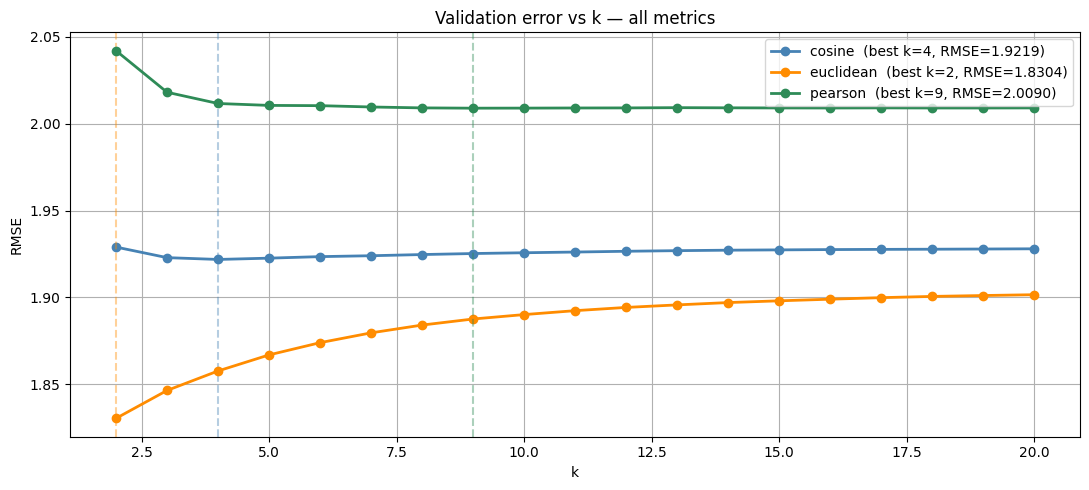

In [20]:

best_ks = plot_knn_error(results, error_metric='rmse')
# best_ks → {'cosine': 5, 'euclidean': 8, 'pearson': 4}

In [21]:
results = evaluate_knn(
    x_val, y_val, sparse_matrix, user_map, item_map,
    k_max=20,
    metrics=['cosine', 'euclidean', 'pearson'],
    error_metric='mae'
)

Evaluating: 100%|██████████| 39036/39036 [03:34<00:00, 181.85it/s]


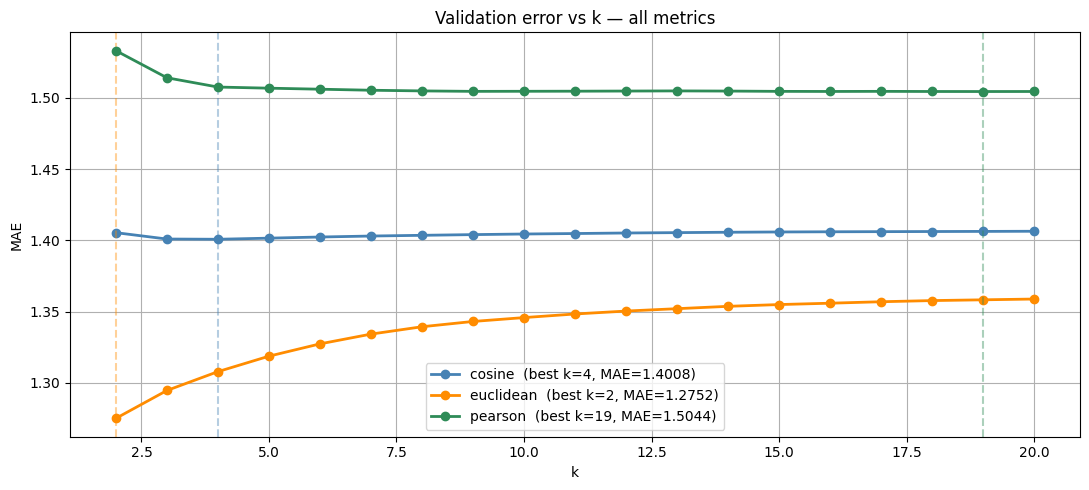

In [22]:
best_ks = plot_knn_error(results, error_metric='mae')
# best_ks → {'cosine': 5, 'euclidean': 8, 'pearson': 4}